In [1]:
import numpy as np
import matplotlib.pyplot as plt

**Part (a)**

Defining functions

In [ ]:
# ODE function
def odefunc1(x, y, E):
  k2 = E - pot1(x)
  return np.array([y[1], -k2*y[0]])

# Potential
def pot1(x):
  if abs(x) > 1.0:
    return 0
  else:
    return -40*(1 - x**3)/2

# Standard RK4 with parameter k, which calls a function f(x, y, k)
def rk4(f,x,y,k,h):
    k1 = h*f(x,y,k)
    k2 = h*f(x + h/2, y + k1/2, k)
    k3 = h*f(x + h/2, y + k2/2, k)
    k4 = h*f(x + h, y + k3, k)
    return y + (k1+2*k2+2*k3+k4)/6

# Caller method for RK4
def caller_rk4(f, xlim, yini, k, N):
    xi, xf = xlim
    yini = np.array(yini)
    xs = np.linspace(xi, xf, N)
    h = xs[1] - xs[0]

    ys = np.zeros(shape=(N, len(yini)))
    ys[0, :] = yini
    y = yini

    for i in range(1, N):
        x = xs[i-1]
        y = rk4(f, x, y, k, h)
        ys[i, :] = np.array(y)

    return xs, ys

# Secant method for finding roots of a function
def secant(ks, method, ybound, tol, maxiter, xlim, N):
    k1, k2 = ks
    iter = 0

    while abs(method(xlim, ybound, k2, N))>tol and iter<maxiter:
        f1 = method(xlim, ybound, k1, N)
        f2 = method(xlim, ybound, k2, N)
        k1, k2 = k2, (f2*k1 - f1*k2)/(f2 - f1)
        iter += 1
        # print(iter, k1, k2, method(xlim, ybound, k2, N))

    if iter == maxiter:
        return iter, None
    else:
        return iter, k2

# Function for calculating score for an energy eigenvalue
def score1(xlim, ybound, E, N):
    # Starting from left
    yinil = (ybound[0], 1e-2)
    xsl, ysl = caller_rk4(odefunc1, xlim, yinil, E, N)

    # Checking for the xval where x = -1.0
    al = np.abs(xsl + 1.0)
    indicesl = np.where(al == np.min(al))
    nl = indicesl[0][0]

    # Starting from right
    yinir = (ybound[1], 1e-2)
    xsr, ysr = caller_rk4(odefunc1, xlim[::-1], yinir, E, N)

    # Checking for xval where x = -1.0
    ar = np.abs(xsr + 1.0)
    indicesr = np.where(ar == np.min(ar))
    nr = indicesr[0][0]

    # Normalising the wavefunction so that their amplitudes match at -1.0
    ysr = (ysl[nl][0]/ysr[nr][0])*ysr

    # Difference of derivatives
    return ysl[nl][1] - ysr[nr][1]

Setting parameters and calculating scores

In [ ]:
N = 201
Es = np.linspace(-40, 0, 1000)
tol = 1e-5
maxiter = 50
xlim = (-2.0, 2.0)
ybound = (0.0, 0.0)
yini = (ybound[0], 1e-2)

scores = np.array([score1(xlim, ybound, E, N) for E in Es])

Plotting scores

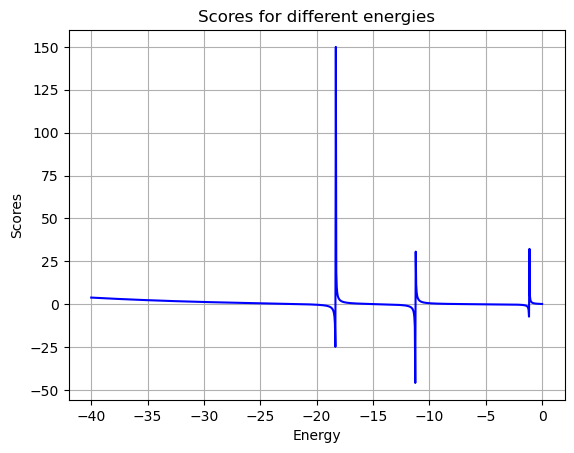

In [4]:
plt.plot(Es, scores, "b-")
plt.xlabel("Energy")
plt.ylabel("Scores")
plt.title("Scores for different energies")

plt.grid()
plt.show()

Zooming in near scores = 0

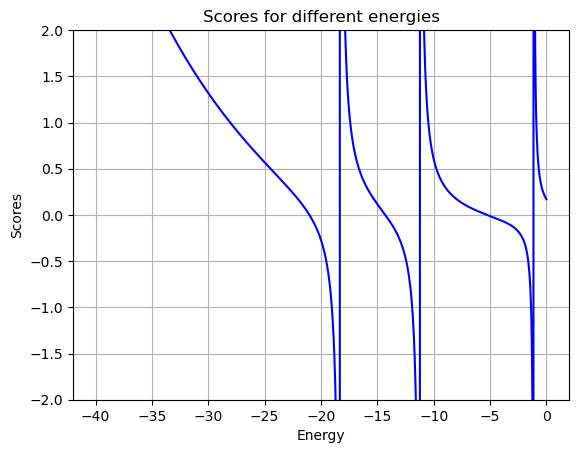

In [5]:
plt.plot(Es, scores, "b-")
plt.xlabel("Energy")
plt.ylabel("Scores")
plt.title("Scores for different energies")
plt.ylim((-2, 2))

plt.grid()
plt.show()

Finding Eigenenergies

In [ ]:
# Checking where the sign of scores changes
indices = np.where(np.sign(scores[:-1]) != np.sign(scores[1:]))[0]
Eeigens = []
secant_tol = 1e-3   # To avoid storing the same eigenvalues caused by vertical lines in the scores plot.
k = 0

# Finding eigenenergies
for i in indices:
    ks = (Es[i], Es[i+1])
    it, E = secant(ks, score1, ybound, tol, maxiter, xlim, N)

    # Avoiding duplicate energies
    if not any(abs(E-e) < secant_tol for e in Eeigens):
        Eeigens.append(E)
        print(f"E_{k}:", E)
        k += 1

E_0: -21.029671583087033
E_1: -14.29870538894345
E_2: -5.262545192368712


Finding and plotting eigenfunctions

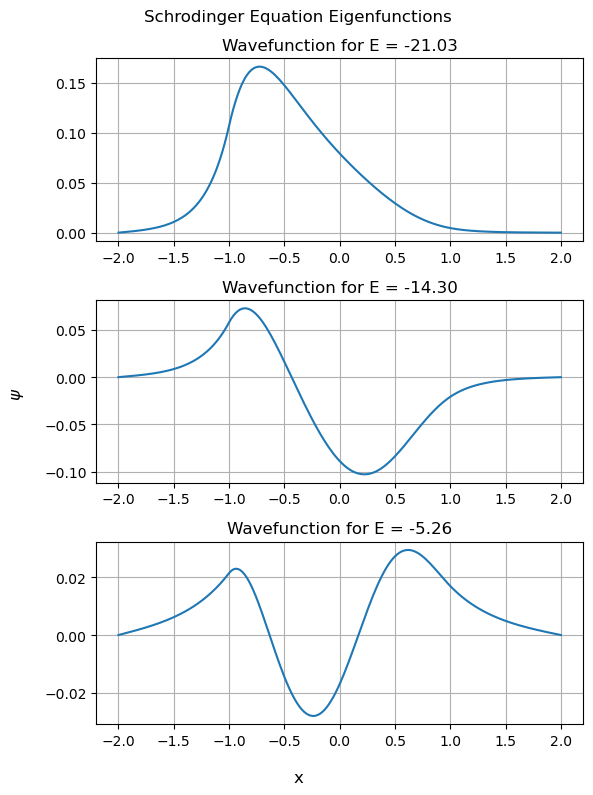

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(6, 8))

for i in range(3):
    # Calculating eigenfunctions
    xs, ys = caller_rk4(odefunc1, xlim, yini, Eeigens[i], N)
    y = ys[:, 0]

    # Plotting
    ax[i].plot(xs, y)
    ax[i].set_title(f"Wavefunction for E = {Eeigens[i]: 0.2f}")
    ax[i].grid()

fig.supxlabel("x")
fig.supylabel("$\\psi$")
fig.suptitle("Schrodinger Equation Eigenfunctions")

plt.tight_layout()
plt.show()

**Part (b)**

Defining functions

In [53]:
# Potential
def pot2(x):
    return x**2

# ODE function for V(x) = x^2
def odefunc2(x, y, E):
    k2 = E - pot2(x)
    return np.array([y[1], -k2*y[0]])

# Function for calculating score for even eigenvalues
def score_even(xlim, ybound, E, N):
    yini = (1.0, 0.0)   # psi(0) = 0 and psi'(0) = 1 for even eigenfunctions
    xs, ys = caller_rk4(odefunc2, xlim, yini, E, N)

    # Wavefunction at x = xf
    return ys[-1, 0]

# Function for calculating score for odd eigenvalues
def score_odd(xlim, ybound, E, N):
    yini = (0.0, 1.0)   # psi(0) = 1 and psi'(0) = 0 for odd eigenfunctions
    xs, ys = caller_rk4(odefunc2, xlim, yini, E, N)

    # Wavefunction at x = xf
    return ys[-1, 0]


Defining parameters and calculating scores

In [56]:
N = 201
Es = np.linspace(0, 12, 500)
xlim = (0, 5)   # Since potential is symmetric, we evaluate only the positive side

scores_even = [score_even(xlim, ybound, E, N) for E in Es]
scores_odd = [score_odd(xlim, ybound, E, N) for E in Es]

Finding even eigenvalues

In [57]:
indices_even = np.where(np.sign(scores_even[:-1]) != np.sign(scores_even[1:]))[0]
Eeigens_even = []
secant_tol = 1e-3
k = 0

for i in indices_even:
    ks = (Es[i], Es[i+1])
    it, E = secant(ks, score_even, ybound, tol, maxiter, xlim, N)

    Eeigens_even.append(E)
    print(f"E_{2*k}:", E)
    k += 1

E_0: 1.0000000043706796
E_2: 5.000000432233685
E_4: 9.00002677337387


Finding odd eigenvalues

In [58]:
indices_odd = np.where(np.sign(scores_odd[:-1]) != np.sign(scores_odd[1:]))[0]
Eeigens_odd = []
k = 0

for i in indices_odd:
    ks = (Es[i], Es[i+1])
    it, E = secant(ks, score_odd, ybound, tol, maxiter, xlim, N)

    Eeigens_odd.append(E)
    print(f"E_{2*k+1}:", E)
    k += 1

E_1: 3.0000000683811665
E_3: 7.000003153973197
E_5: 11.000199696257205


Finding and plotting eigenfunctions

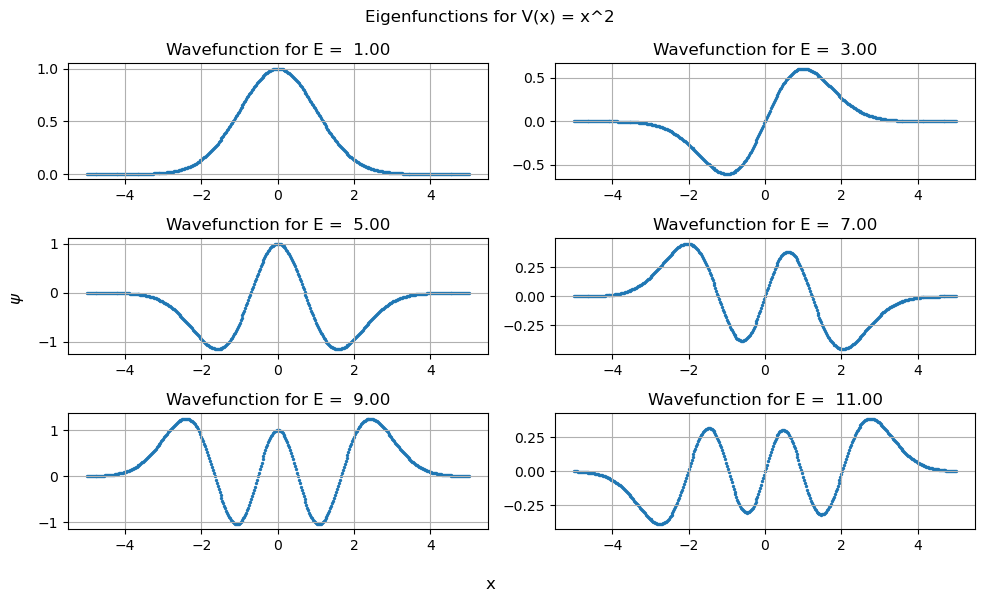

In [63]:
# Eeigens contains all eigenvalues
Eeigens = Eeigens_even + Eeigens_odd
Eeigens.sort()

fig, ax = plt.subplots(3, 2, figsize=(10, 6))
k = 0

for i in range(3):
    for j in range(2):
        # Calculating eigenfunctions
        if k%2 == 0:    # Even eigenfunctions
            yini = (1.0, 0.0)
        else:       # Odd eigenfunctions
            yini = (0.0, 1.0)
            
        xs, ys = caller_rk4(odefunc2, xlim, yini, Eeigens[k], N)
        psi = ys[:, 0]
        xs_full = np.concatenate((xs[:], -xs[::-1]))

        if k%2 == 0:    # Eigenfunctions have same sign on both sides
            psi_full = np.concatenate((psi[:], psi[::-1]))
        else:       # Eigenfunctions have different sign on opposite sides
            psi_full = np.concatenate((psi[:], -psi[::-1]))

        # Plotting
        ax[i, j].scatter(xs_full, psi_full, s=2)
        ax[i, j].set_title(f"Wavefunction for E = {Eeigens[k]: 0.2f}")
        ax[i, j].grid()
        k += 1

fig.supxlabel("x")
fig.supylabel("$\\psi$")
fig.suptitle("Eigenfunctions for V(x) = x^2")

plt.tight_layout()
plt.show()